# 04 — Build a Spatial VQA Dataset from COCO (LLM-assisted)

Goal: Convert COCO (images + instance annotations) into a spatial VQA dataset for fine-tuning VLMs/MLLMs.

Pipeline: COCO → spatial facts (geometry) → LLM generates questions/answers → curate → split → export.

## 1. Setup & Configuration

We define paths, install requirements, and set dataset generation parameters.
Outputs: a printed config dictionary for reproducibility.

In [ ]:
import os, json, random, hashlib
from dataclasses import dataclass, asdict
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# -----------------------
# Windows-friendly paths
# -----------------------
COCO_ROOT = r"E:\1_Codes\Multimodal_Datasets_Generative_Reasoning\data\raw\train2017"
ANN_ROOT  = r"E:\1_Codes\Multimodal_Datasets_Generative_Reasoning\data\raw\annotations"

annFile = os.path.join(ANN_ROOT, "instances_train2017.json")
assert os.path.exists(annFile), "Annotation file not found!"

OUT_DIR   = os.path.join("data", "generated", "coco_spatial_vqa")
CACHE_DIR = os.path.join(OUT_DIR, "cache")
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

# -----------------------
# Global knobs
# -----------------------
SEED = 42
N_IMAGES = 200
QUESTIONS_PER_IMAGE = 6
MAX_OBJECTS_PER_IMAGE = 12
MIN_BBOX_AREA = 32 * 32  # pixels

MODEL_NAME = "gpt-4.1-mini"  # placeholder
TEMPERATURE = 0.3

config = dict(
    SEED=SEED, N_IMAGES=N_IMAGES, QUESTIONS_PER_IMAGE=QUESTIONS_PER_IMAGE,
    MAX_OBJECTS_PER_IMAGE=MAX_OBJECTS_PER_IMAGE, MIN_BBOX_AREA=MIN_BBOX_AREA,
    COCO_ROOT=COCO_ROOT, annFile=annFile, OUT_DIR=OUT_DIR,
    MODEL_NAME=MODEL_NAME, TEMPERATURE=TEMPERATURE,
)
print(json.dumps(config, indent=2))
random.seed(SEED); np.random.seed(SEED)


{
  "SEED": 42,
  "N_IMAGES": 200,
  "QUESTIONS_PER_IMAGE": 6,
  "MAX_OBJECTS_PER_IMAGE": 12,
  "MIN_BBOX_AREA": 1024,
  "COCO_ROOT": "E:\\1_Codes\\Multimodal_Datasets_Generative_Reasoning\\data\\raw\\train2017",
  "annFile": "E:\\1_Codes\\Multimodal_Datasets_Generative_Reasoning\\data\\raw\\annotations\\instances_train2017.json",
  "OUT_DIR": "data\\generated\\coco_spatial_vqa",
  "MODEL_NAME": "gpt-4.1-mini",
  "TEMPERATURE": 0.3
}


## 2. Load COCO & Sample Images

We load the COCO API, sample images deterministically, and visualize a few samples with bbox overlays.
Output: a small visualization grid.

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
loading annotations into memory...
Done (t=7.27s)
creating index...
index created!
Total COCO images: 118287
Sampled images: 200


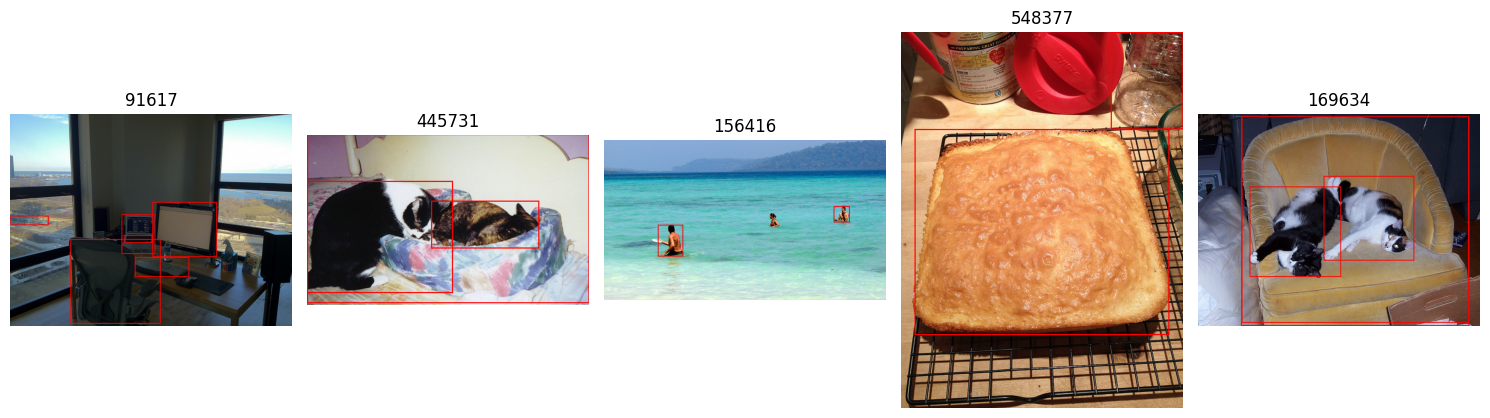

In [18]:
%pip install pycocotools
from pycocotools.coco import COCO

coco = COCO(annFile)

img_ids = coco.getImgIds()
sampled_img_ids = random.sample(img_ids, min(N_IMAGES, len(img_ids)))

print(f"Total COCO images: {len(img_ids)}")
print(f"Sampled images: {len(sampled_img_ids)}")

def visualize_coco_sample(img_id):
    img_info = coco.loadImgs(img_id)[0]
    img_path = os.path.join(COCO_ROOT, img_info["file_name"])
    image = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(image)

    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)

    # filter + keep top objects by area (up to MAX_OBJECTS_PER_IMAGE)
    objs = []
    for ann in anns:
        x, y, w, h = ann["bbox"]
        area = w * h
        if area >= MIN_BBOX_AREA:
            objs.append((area, ann))
    objs.sort(reverse=True, key=lambda t: t[0])
    objs = objs[:MAX_OBJECTS_PER_IMAGE]

    for _, ann in objs:
        x, y, w, h = ann["bbox"]
        draw.rectangle([x, y, x+w, y+h], outline="red", width=2)

    return image

num_vis = min(5, len(sampled_img_ids))
plt.figure(figsize=(15, 5))
for i, img_id in enumerate(sampled_img_ids[:num_vis]):
    plt.subplot(1, num_vis, i+1)
    plt.imshow(visualize_coco_sample(img_id))
    plt.axis("off")
    plt.title(f"{img_id}")
plt.tight_layout()
plt.show()

## 3. Extract Spatial Facts (Geometry, Not LLM)

We convert COCO instance annotations into structured spatial facts:
- object centers, normalized positions and areas
- pairwise relations (left/right/above/below/overlap)
- normalized distances (image-size invariant)

Output: `facts.jsonl` (one record per image).

In [19]:
def bbox_center(b):
    x, y, w, h = b
    return (x + w/2.0, y + h/2.0)

def iou(b1, b2):
    x1,y1,w1,h1 = b1
    x2,y2,w2,h2 = b2
    xa = max(x1, x2); ya = max(y1, y2)
    xb = min(x1+w1, x2+w2); yb = min(y1+h1, y2+h2)
    inter = max(0, xb-xa) * max(0, yb-ya)
    union = w1*h1 + w2*h2 - inter
    return inter/union if union > 0 else 0.0

def pair_relation(a, b, eps=1e-6):
    ax, ay = a["center_norm"]
    bx, by = b["center_norm"]
    rel = []
    if ax < bx - 0.05: rel.append("left_of")
    if ax > bx + 0.05: rel.append("right_of")
    if ay < by - 0.05: rel.append("above")   # note: y increases downward; normalize still works with convention
    if ay > by + 0.05: rel.append("below")
    if a["iou_with"][b["obj_id"]] > 0.1: rel.append("overlap")
    return rel

facts_path = os.path.join(OUT_DIR, "facts.jsonl")

with open(facts_path, "w", encoding="utf-8") as f:
    for img_id in tqdm(sampled_img_ids, desc="Extract facts"):
        img_info = coco.loadImgs(img_id)[0]
        W, H = img_info["width"], img_info["height"]

        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        # filter + top-K
        filtered = []
        for ann in anns:
            x, y, w, h = ann["bbox"]
            area = w*h
            if area >= MIN_BBOX_AREA:
                filtered.append((area, ann))
        filtered.sort(reverse=True, key=lambda t: t[0])
        filtered = filtered[:MAX_OBJECTS_PER_IMAGE]
        anns_k = [ann for _, ann in filtered]

        objects = []
        for ann in anns_k:
            cat = coco.loadCats([ann["category_id"]])[0]["name"]
            cx, cy = bbox_center(ann["bbox"])
            obj = {
                "obj_id": int(ann["id"]),
                "category": cat,
                "bbox": [float(v) for v in ann["bbox"]],
                "area": float(ann["bbox"][2] * ann["bbox"][3]),
                "center": [float(cx), float(cy)],
                "center_norm": [float(cx / W), float(cy / H)],
                "area_norm": float((ann["bbox"][2] * ann["bbox"][3]) / (W * H)),
            }
            objects.append(obj)

        # precompute IOU map
        for a in objects:
            a["iou_with"] = {}
            for b in objects:
                if a["obj_id"] == b["obj_id"]:
                    continue
                a["iou_with"][b["obj_id"]] = float(iou(a["bbox"], b["bbox"]))

        relations = []
        distances = []
        for i in range(len(objects)):
            for j in range(i+1, len(objects)):
                a, b = objects[i], objects[j]
                rel_ab = pair_relation(a, b)
                rel_ba = pair_relation(b, a)
                if rel_ab:
                    relations.append({"a": a["obj_id"], "b": b["obj_id"], "types": rel_ab})
                if rel_ba:
                    relations.append({"a": b["obj_id"], "b": a["obj_id"], "types": rel_ba})

                ax, ay = a["center_norm"]
                bx, by = b["center_norm"]
                d = float(np.sqrt((ax-bx)**2 + (ay-by)**2))
                distances.append({"a": a["obj_id"], "b": b["obj_id"], "d_norm": d})

        record = {
            "image_id": int(img_id),
            "file_name": img_info["file_name"],
            "width": int(W),
            "height": int(H),
            "objects": objects,
            "relations": relations,
            "distances": distances,
        }
        f.write(json.dumps(record) + "\n")

print("Wrote:", facts_path)

Extract facts: 100%|██████████| 200/200 [00:00<00:00, 6084.30it/s]

Wrote: data\generated\coco_spatial_vqa\facts.jsonl


## 4. Define VQA Schema

We enforce a strict JSON schema for each QA item to make the dataset:
- easy to audit (supporting facts included)
- easy to fine-tune (question → answer)
- easy to slice (type/difficulty)

Output: a validator function used during generation.

In [20]:
REQUIRED_KEYS = {"id", "image_id", "question", "answer", "question_type", "difficulty", "supporting_facts"}

def validate_item(x: dict) -> None:
    missing = REQUIRED_KEYS - set(x.keys())
    if missing:
        raise ValueError(f"Missing keys: {missing}")
    assert isinstance(x["question"], str) and len(x["question"]) > 0
    assert isinstance(x["answer"], str) and len(x["answer"]) > 0
    assert x["difficulty"] in {"easy", "medium", "hard"}

## 5. Prompt Templates

We define minimal prompt templates per question type (relation, distance, size, counting, multi-hop).
Output: prompt strings used by the LLM wrapper.

In [21]:
PROMPTS = {
  "relation_binary": "...",
  "distance_compare": "...",
  "size_compare": "...",
  "count_relation": "...",
  "two_hop": "...",
}

## 6. LLM Wrapper

We call an LLM to convert spatial facts into natural language Q/A pairs.
We cache raw responses and enforce JSON-only output.
Output: a function `llm_generate_items(facts)->list[dict]`.

In [ ]:
# placeholder: you will plug in OpenAI/HF/local later


## 7. Generate Spatial VQA

For each image’s facts, generate multiple QA items across types, validate schema, and write JSONL.
Output: `spatial_vqa.jsonl`.

In [ ]:
# generation loop placeholder


## 8. Curation

Deduplicate, remove trivial/ambiguous QAs, balance by type and difficulty.
Output: `spatial_vqa_curated.jsonl`.

In [ ]:
# filter + balance placeholder


## 9. Dataset Splits

We split by image_id hash to avoid leakage across splits.
Outputs: `train.jsonl`, `val.jsonl`, `test.jsonl`.

In [ ]:
# split placeholder


## 10. Dataset Report

We compute counts by type/difficulty and show example items.
Output: summary tables and a few sample QAs.

In [ ]:
# report placeholder


## 11. Export for Fine-tuning

We export to a simple SFT format (image path + question + answer), and optionally a chat format.
Outputs: `sft_train.jsonl`, `sft_val.jsonl`.

In [ ]:
# export placeholder
